In [1]:
import os
print(os.getcwd())

/Users/pn254/Documents/osmo-odor-analysis/lee_et_al_2023/notebooks


In [2]:
os.chdir("/Users/pn254/Documents/osmo-odor-analysis")
print(os.getcwd())

/Users/pn254/Documents/osmo-odor-analysis


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
import seaborn as sns
from lee_et_al_2023.src import base

In [4]:
url = "https://raw.githubusercontent.com/ARY2260/openpom/main/openpom/data/curated_datasets/curated_GS_LF_merged_4983.csv"
input_file = pd.read_csv(url)

In [5]:
print(base.DATA_PATH)

/Users/pn254/Documents/osmo-odor-analysis/lee_et_al_2023/data


In [6]:
pc_df = pd.read_csv(base.DATA_PATH / 'fig_1_pc_data.csv')

pca_gnn = pc_df[['gnn_pc1', 'gnn_pc2']].values
pca_fp = pc_df[['fp_pc1', 'fp_pc2']].values
pca_label = pc_df[['label_pc1', 'label_pc2']].values
pc_df

,gnn_pc1,gnn_pc2,fp_pc1,fp_pc2,label_pc1,label_pc2,floral,muguet,lavender,jasmin,meaty,savory,beefy,roasted,alcoholic,cognac,fermented,winey
0,4.099059,-4.683025,4.309764,-2.054179,-1.804926,-0.781862,False,False,False,False,False,False,False,False,False,False,False,False
1,-4.198137,12.037624,-0.876388,0.906919,0.317769,1.389603,False,False,False,False,False,False,False,False,False,False,False,False
2,8.839882,-1.273348,-0.558230,-0.953559,-0.419952,-4.479056,False,False,False,False,False,False,False,False,True,True,False,False
3,-2.116059,6.074374,1.008225,3.528770,0.055796,2.238501,True,False,False,False,False,False,False,False,False,False,False,False
4,-3.135273,2.849107,0.328393,5.025255,-0.768493,0.171850,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4973,4.660874,-6.750710,2.773708,-1.301833,0.294133,-0.329246,False,False,False,False,False,False,False,False,False,False,False,False
4974,-6.248957,0.631847,-4.244362,-0.891121,-0.727464,1.372728,False,False,False,False,False,False,False,False,False,False,False,False
4975,9.102892,4.950864,-1.531205,-1.444009,5.465875,-1.731097,False,False,False,False,False,False,False,False,False,False,True,False
4976,4.804634,7.902617,-1.154713,1.156712,2.708742,0.281732,False,False,False,False,True,False,False,False,False,False,False,False


/var/folders/t6/7zlqsbq91v9d5jdv91sbsvds8rzyfz/T/ipykernel_61530/2726616433.py:49: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], marker='s', c=fg_color, label=label)
/var/folders/t6/7zlqsbq91v9d5jdv91sbsvds8rzyfz/T/ipykernel_61530/2726616433.py:49: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], marker='s', c=fg_color, label=label)
/var/folders/t6/7zlqsbq91v9d5jdv91sbsvds8rzyfz/T/ipykern

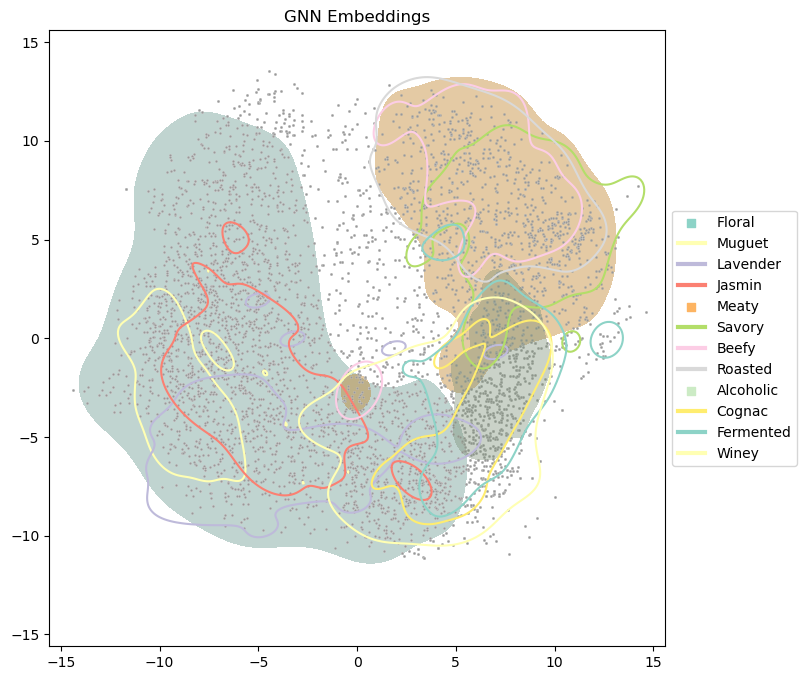

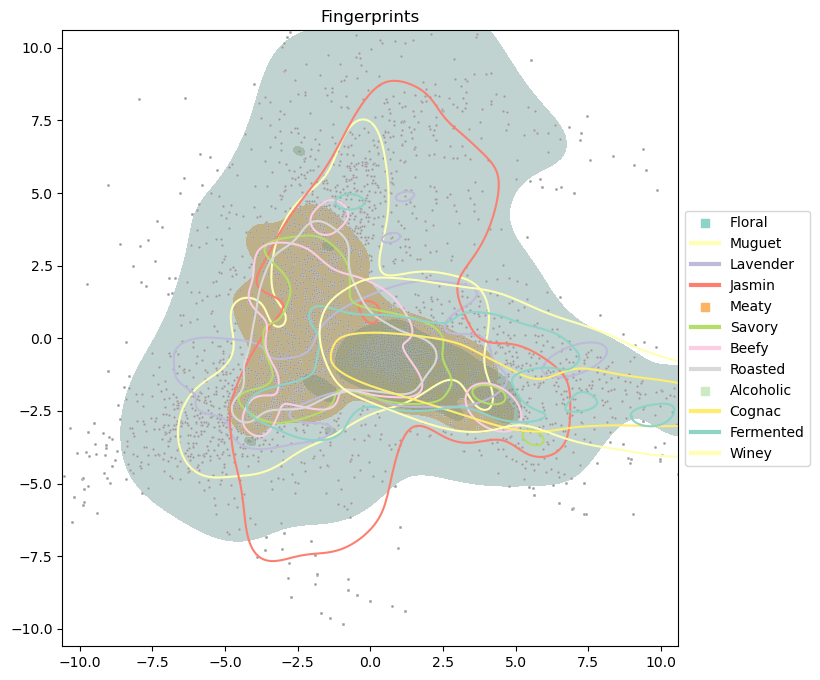

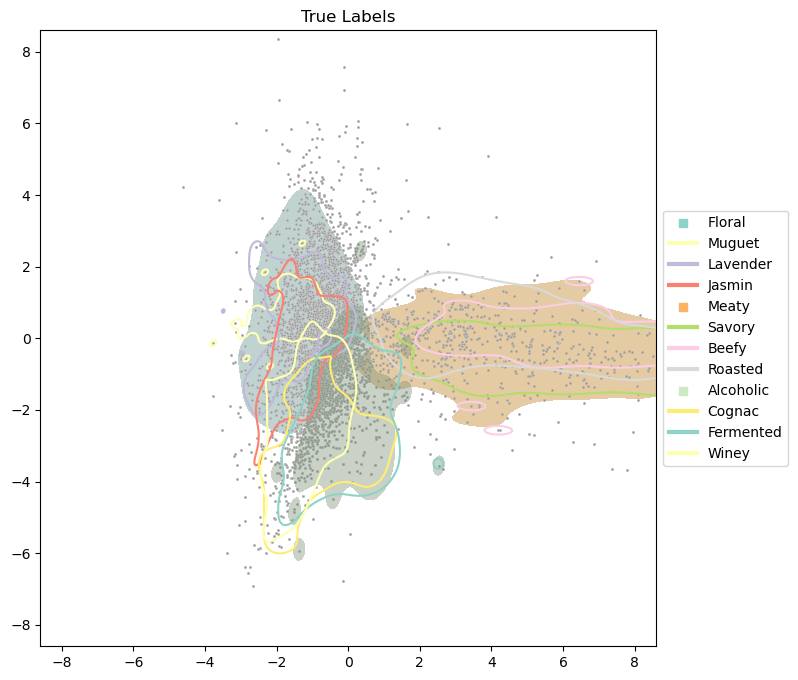

In [7]:
def plot_islands(bg_points,
                 bg_name,
                 *fg_specs,
                 alpha = 0.4,
                 z_limit = 15,
                 colors=None):
    """Plot islands in a background sea of points.

    This command executes matplotlib.pyplot commands as side effects.
    Use plt.figure() to control where these outputs get generated.

    Args:
    bg_points: Array of shape (n_points, 2) indicating x,y coordinates
        of any background points.
    bg_name: Name of background points
    *fg_specs: Repeated island specifications. Allowable dict keys:
        data - array of shape (n_points, 2)
        label - str, name of the island
        color - RGB, color of the island
        scatter - bool, whether to add the point scatters
        scatter_size - int, radius of scatter points in pixel
        filled - bool, whether to fill the island
        levels_to_plot - List[float], percentiles of the KDE to plot.
    alpha: Transparency of island color fill.
    z_limit: Plotting boundaries of the plot.
    """
    default_fg_colors = colors or sns.color_palette('Set3', len(fg_specs))

    sns.scatterplot(x=bg_points[:, 0], y=bg_points[:, 1],
              s=3, color='0.60', label=bg_name)
    for fg_color, fg_spec in zip(default_fg_colors, fg_specs):
        fg_color = fg_spec.get('color', fg_color)
        fg_scatter = fg_spec.get('scatter', False)
        fg_scatter_size = fg_spec.get('scatter_size', 5)
        fg_filled = fg_spec.get('filled', False)
        fg_level_to_plot = fg_spec.get('level_to_plot', 0.25)
        x, y = fg_spec['data'][:, 0], fg_spec['data'][:, 1]
        label = fg_spec['label']
        if fg_scatter:
            sns.scatterplot(x, y, s=fg_scatter_size, color=fg_color)
        if fg_filled:
            sns.kdeplot(x=x, y=y, color=fg_color, fill=True,
                      thresh=fg_level_to_plot, alpha=alpha, levels=2, bw_method=0.3)
        else:
            sns.kdeplot(x=x, y=y, color=fg_color, fill=False,
                      thresh=fg_level_to_plot, levels=2, bw_method=0.3)
        # Generate the legend entry
        if fg_filled:
            plt.scatter([], [], marker='s', c=fg_color, label=label)
        else:
            plt.plot([], [], c=fg_color, linewidth=3, label=label)
    plt.xlim([-z_limit - 0.6, z_limit + 0.6])
    plt.ylim([-z_limit - 0.6, z_limit + 0.6])
    plt.gca().set_aspect('equal', adjustable='box')
    

def plot_odor_islands(pca_space, z_limit=15):
    plt.figure(figsize=(12, 8))
    color_palette = sns.color_palette('Set3', 15)
    fg_specs = []
    i = 0
    for main_group, subgroups in [('floral', ['muguet', 'lavender', 'jasmin']),
                                ('meaty', ['savory', 'beefy', 'roasted']),
                                ('alcoholic', ['cognac', 'fermented', 'winey']),
                                ]:
        main_embeddings = pca_space[pc_df[main_group]]
        fg_specs.append({'data': main_embeddings,
                        'filled': True,
                        'scatter': False,
                        'level_to_plot': 0.1,
                        'label': main_group.capitalize()})

        for subgroup in subgroups:
            island_embeddings = pca_space[pc_df[subgroup]]
            fg_specs.append({'data': island_embeddings,
                          'filled': False,
                          'scatter': False,
                          'level_to_plot': 0.2,
                          'label': subgroup.capitalize()})
        plot_islands(pca_space, None, *fg_specs, colors=color_palette[i:i+4], z_limit=z_limit)
        i += 5
        fg_specs = []
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plot_odor_islands(pca_gnn, z_limit=15)
plt.title('GNN Embeddings')
plot_odor_islands(pca_fp, z_limit=10)
plt.title('Fingerprints')
plot_odor_islands(pca_label, z_limit=8)
plt.title('True Labels')
plt.show()

In [11]:
#input_file.merge(pc_df)

,nonStereoSMILES,descriptors,alcoholic,aldehydic,alliaceous,almond,amber,animal,anisic,apple,...,waxy,weedy,winey,woody,gnn_pc1,gnn_pc2,fp_pc1,fp_pc2,label_pc1,label_pc2
0,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,4.099059,-4.683025,4.309764,-2.054179,-1.804926,-0.781862
1,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,-4.198137,12.037624,-0.876388,0.906919,0.317769,1.389603
2,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,6.553688,4.598550,-0.021284,0.049330,0.536504,0.019619
3,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,-5.686531,2.445645,-5.699184,-2.575747,-0.937351,3.732202
4,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,-12.005396,-3.727647,-3.543021,-1.253298,0.082540,1.061446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10208277,CC1CCC(C(C)C)C(OCC(C)(O)CO)C1,mint;cooling,0,0,0,0,0,0,0,0,...,0,0,0,0,7.119741,0.458904,0.391362,-0.676998,-0.067061,-0.766220
10208278,CC1CCC(C(C)C)C(OCC(C)(O)CO)C1,mint;cooling,0,0,0,0,0,0,0,0,...,0,0,0,0,5.859369,3.341572,-4.203703,-2.260930,-0.242646,-1.133364
10208279,CC1CCC(C(C)C)C(OCC(C)(O)CO)C1,mint;cooling,0,0,0,0,0,0,0,0,...,0,0,0,0,4.660874,-6.750710,2.773708,-1.301833,0.294133,-0.329246
10208280,CC1CCC(C(C)C)C(OCC(C)(O)CO)C1,mint;cooling,0,0,0,0,0,0,0,0,...,0,0,0,0,-6.248957,0.631847,-4.244362,-0.891121,-0.727464,1.372728


In [8]:
input_file

,nonStereoSMILES,descriptors,alcoholic,aldehydic,alliaceous,almond,amber,animal,anisic,apple,...,tropical,vanilla,vegetable,vetiver,violet,warm,waxy,weedy,winey,woody
0,CC(O)CN,fishy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CCC(=O)C(=O)O,fatty;lactonic;sweet;caramellic;creamy,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,O=C(O)CCc1ccccc1,rose;floral;fatty;sweet;musk;cinnamon;balsamic,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,OCc1ccc(O)cc1,medicinal;phenolic;fruity;nutty;bitter;sweet;a...,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,O=Cc1ccc(O)cc1,phenolic;woody;nutty;vanilla;hay;metallic;swee...,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4978,O=c1[nH]cnc2c1ncn2C1OC(COP(=O)([O-])[O-])C(O)C...,odorless,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4979,Nc1nc2c(ncn2C2OC(COP(=O)([O-])[O-])C(O)C2O)c(=...,odorless,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4980,Nc1nc2c(ncn2C2OC(COP(=O)([O-])[O-])C(O)C2O)c(=...,odorless,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4981,CCC1SC(C)=NC(C)S1,alliaceous,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
pc_df.to_excel("output1.xlsx")

In [10]:
input_file.to_excel("output2.xlsx")

In [11]:
pwd

'/Users/pn254/Documents/osmo-odor-analysis'